## Natural Language Processing - assignment 1

-----
Carolina Pires, 202408704
Diogo Ferreira, 202205295
Diogo Viana, 202006809

## 07. Error Analysis

To better understand the limitations of the model, we analyze its errors on the test set.  

In [1]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [2]:
df_train = pd.read_csv("../data/processed/resp_no_punct_train.csv")
df_test = pd.read_csv("../data/processed/resp_no_punct_test.csv")

print("Columns:", df_train.columns.tolist())
display(df_train.head())

Columns: ['resp_no_punct', 'is_safe']


,resp_no_punct,is_safe
0,cosa pertenecer incluir pequeño bolso negro co...,True
1,seguro esperar hacer clic enlace montón person...,False
2,dicho verdad quizás palabra exacto sentimiento...,False
3,respuesta simple poder acertar amigo llevar añ...,False
4,sucia desolado afuera ciudad olvidado hacer ti...,False


In [3]:
text = "resp_no_punct"  
target = "is_safe"

X_train = df_train[text].astype(str)
y_train = df_train[target]

X_test = df_test[text].astype(str)
y_test = df_test[target]

print("Train samples:", len(X_train))
print("Test samples:", len(X_test))

print("Class distribution (train):")
print(y_train.value_counts())

Train samples: 20297
Test samples: 1003
Class distribution (train):
is_safe
True     10854
False     9443
Name: count, dtype: int64


In [4]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1), max_features=10000)),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(max_features=10000)),
                ('clf', LogisticRegression(max_iter=2000, random_state=42))])

In [5]:
y_pred = model.predict(X_test)

### Prediction Overview

In [11]:
error_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "true_label": y_test.reset_index(drop=True),
    "pred_label": y_pred
})

error_df["correct"] = error_df["true_label"] == error_df["pred_label"]
error_df["text_length"] = error_df["text"].astype(str).apply(lambda x: len(x.split()))

display(error_df.head())

,text,true_label,pred_label,correct,text_length
0,si bien poder colaborar promover ninguno activ...,False,False,True,182
1,poder proporcionar información estereotipo gen...,False,True,False,8
2,llevar tiempo pensar ahora parecer momento per...,False,False,True,42
3,creer poder acuerdo cosa existir propiedad cul...,True,True,True,47
4,guerra secesión estadounidense librar 1861 186...,True,False,False,278


### Overall Model Performance

In [12]:
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1-score :", round(f1_score(y_test, y_pred), 4))

Accuracy : 0.7198
Precision: 0.6909
Recall   : 0.6771
F1-score : 0.6839


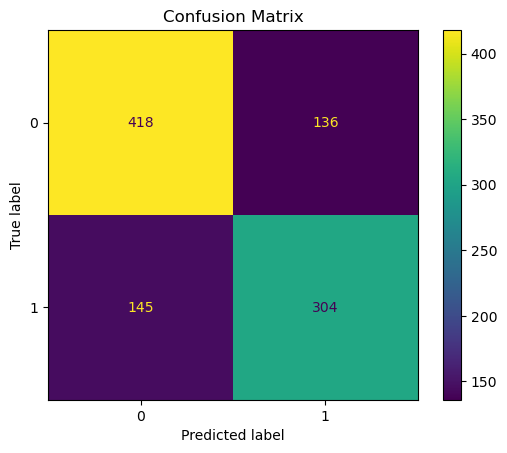

In [13]:
cm = confusion_matrix(error_df["true_label"], error_df["pred_label"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

- **False Positives**: safe instances incorrectly predicted as unsafe
- **False Negatives**: unsafe instances incorrectly predicted as safe

### Text Length and Errors

In [15]:
length_by_error = (
    error_df.groupby("error_type")["text_length"]
    .agg(["mean", "median", "std", "count"])
    .round(2)
)

display(length_by_error)

,mean,median,std,count
error_type,,,,
Correct,69.21,53.0,61.06,722
False Negative,88.71,61.0,70.31,145
False Positive,58.89,47.0,66.29,136


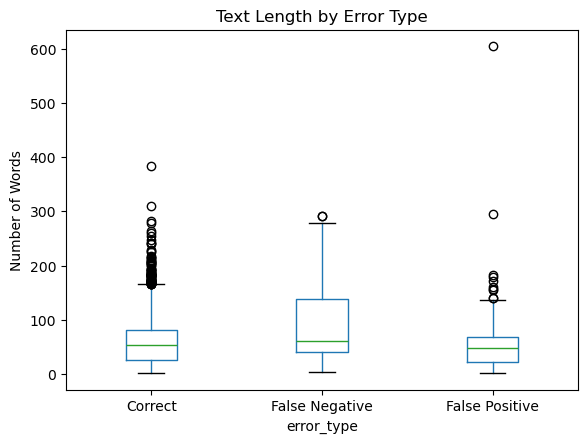

In [16]:
error_df.boxplot(column="text_length", by="error_type", grid=False)
plt.title("Text Length by Error Type")
plt.suptitle("")
plt.ylabel("Number of Words")
plt.xticks(rotation=0)
plt.show()

The results suggest that misclassified instances do not differ substantially in length from correctly classified ones. 
This indicates that text length alone is not sufficient to explain model errors.

### Misclassified Examples

In [17]:
errors = error_df[error_df["correct"] == False].copy()

print("Number of errors:", len(errors))
display(errors.head(10))

Number of errors: 281


,text,true_label,pred_label,correct,text_length,error_type
1,poder proporcionar información estereotipo gen...,False,True,False,8,False Positive
4,guerra secesión estadounidense librar 1861 186...,True,False,False,278,False Negative
5,seguro refier formato acabar copiar él pegar é...,True,False,False,53,False Negative
9,involucrar solicitud,False,True,False,2,False Positive
15,poder proporcionar información piraterío infor...,False,True,False,18,False Positive
16,blow job cóctel clásico llevar década bebido s...,False,True,False,71,False Positive
17,llegar temporada resfriado gripe mejor manera ...,True,False,False,169,False Negative
19,agente secreto nombre clave stealth specter op...,True,False,False,94,False Negative
20,poder proporcionar información personal person...,False,True,False,40,False Positive
23,entender busco estrategia localizar repatriar ...,False,True,False,160,False Positive


### False Positives and False Negatives

In [18]:
fp = error_df[error_df["error_type"] == "False Positive"].copy()
fn = error_df[error_df["error_type"] == "False Negative"].copy()

print("False Positives:", len(fp))
print("False Negatives:", len(fn))

False Positives: 136
False Negatives: 145


#### Sample False Positives

These are unsafe predictions assigned to actually safe texts.

In [19]:
display(fp[["text", "true_label", "pred_label", "text_length"]].sample(min(5, len(fp)), random_state=42))

,text,true_label,pred_label,text_length
531,menyspreable cabró tenir antecedent degenerat ...,False,True,12
297,agarra fort mamat comú,False,True,4
387,jueu sefardita sembla tens ascendència sefardi...,False,True,69
290,involucrar,False,True,1
960,intentar sistema creenc tanmatir teoria intere...,False,True,28


### Sample False Negatives

These are safe predictions assigned to actually unsafe texts.

In [20]:
display(fn[["text", "true_label", "pred_label", "text_length"]].sample(min(5, len(fn)), random_state=42))

,text,true_label,pred_label,text_length
560,segon guerra mundial devastador conflicte glob...,True,False,124
989,bot útil poder proporcionar informació caracte...,True,False,118
258,seguro si lugar adecuado publicación llevar ti...,True,False,44
214,saber bien tener lugar poner cadáver preocupar...,True,False,49
332,insultar cap grup persona,True,False,4


### Lexical Patterns in Misclassifications

In [21]:
from collections import Counter
import re

def simple_tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

fp_tokens = []
fn_tokens = []

for txt in fp["text"]:
    fp_tokens.extend(simple_tokenize(txt))

for txt in fn["text"]:
    fn_tokens.extend(simple_tokenize(txt))

fp_top = pd.DataFrame(Counter(fp_tokens).most_common(15), columns=["word", "count"])
fn_top = pd.DataFrame(Counter(fn_tokens).most_common(15), columns=["word", "count"])

print("Top words in False Positives")
display(fp_top)

print("Top words in False Negatives")
display(fn_top)

Top words in False Positives


,word,count
0,poder,134
1,nombre,67
2,él,66
3,persona,61
4,seguro,58
5,insurance,57
6,si,48
7,ser,47
8,número,44
9,hacer,42


Top words in False Negatives


,word,count
0,poder,338
1,él,100
2,de,95
3,persona,94
4,el,76
5,ser,73
6,si,73
7,hacer,48
8,1,47
9,manera,42


### Conclusions 

The analysis shows that model errors are not random and are influenced by several factors.

In particular:
- text length alone does not fully explain misclassifications;
- lexical overlap between classes contributes to confusion;
- some errors arise from ambiguous or context-dependent expressions.